In [17]:

import os
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

from utils.utils import download_data, make_sample_table, convert_to_color, read_config, convert_to_artificiel
 

In [18]:
print(os.getcwd())

/workspaces/flairimages/src


In [19]:
config = read_config('../config/config.yaml')

In [20]:
#TODO: use config file to set the data_dir, and in the download_data function, use the config file to set the url

# set no_write to False only once download and prepare the data
# otherwise it only gets the path to the data and sample table
no_write = True

data_dir = os.path.join("/workspaces/flairimages", "data")
toy_dataset_dir = download_data(data_dir=data_dir, type="toy", re_download=False, no_write=no_write)
sample_table_file=make_sample_table(toy_dataset_dir, no_write=no_write)

In [21]:

# read the sample table in csv format
df = pd.read_csv(sample_table_file)
df.head()



,KEY,IMG,MSK
0,I000717,/workspaces/flairimages/data/flair_1_toy_datas...,/workspaces/flairimages/data/flair_1_toy_datas...
1,I000734,/workspaces/flairimages/data/flair_1_toy_datas...,/workspaces/flairimages/data/flair_1_toy_datas...
2,I000883,/workspaces/flairimages/data/flair_1_toy_datas...,/workspaces/flairimages/data/flair_1_toy_datas...
3,I001119,/workspaces/flairimages/data/flair_1_toy_datas...,/workspaces/flairimages/data/flair_1_toy_datas...
4,I001331,/workspaces/flairimages/data/flair_1_toy_datas...,/workspaces/flairimages/data/flair_1_toy_datas...


(512, 512, 5)
uint8
0 255


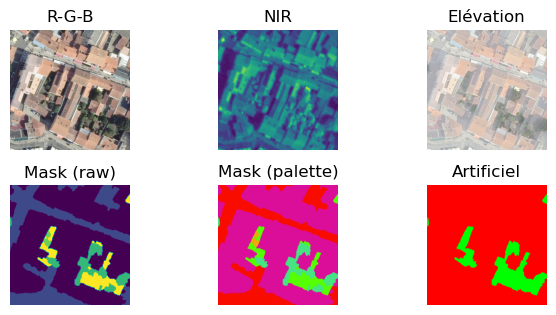

In [22]:
# select a random record from df
id, img_file, msk_file = df.iloc[np.random.randint(df.shape[0])]
with rasterio.open(img_file) as src:
    img = src.read()
    img = np.moveaxis(img, 0, -1)
with rasterio.open(msk_file) as src:
    msk = src.read()
    
print(img.shape)
print(img.dtype)

print(img.min(), img.max())
#
plt.subplot(3,3,1)
plt.imshow(img[:,:,:3])
plt.title("R-G-B")
plt.axis("off")
#
plt.subplot(3,3,2)
plt.imshow(img[:,:,3])
plt.title("NIR")
plt.axis("off")
#
plt.subplot(3,3,3)
plt.imshow(img[:,:,:4])
plt.title("Elévation")
plt.axis("off")
#
plt.subplot(3,3,4)
plt.imshow(msk[0,:,:])
plt.title("Mask (raw)")
plt.axis("off")
#
msk_palette = convert_to_color(arr_2d=msk[0,:,:], palette=config["nomenclature"]["colors"])
plt.subplot(3,3,5)
plt.imshow(msk_palette)
plt.title("Mask (palette)")
plt.axis("off")
#
msk_artificiel = convert_to_artificiel(arr_2d=msk[0,:,:], conf=config)
plt.subplot(3,3,6)
plt.imshow(msk_artificiel)
plt.title("Artificiel")
plt.axis("off")
#
plt.tight_layout()
plt.show()

    
    
